# 02 — Real-data validation: the `vehicle_of_interest` track on UAVDT

`drone`, `dismount`, and `launch_flash` are trained on a synthetic renderer, deliberately,
so each degradation factor could be isolated and controlled. `vehicle_of_interest` is
different: real drone-video ground truth already exists for it (the UAVDT benchmark, Du et
al., ECCV 2018), so this notebook re-runs the same collapse-and-remedy measurement as
`01_domain_gap_evidence.ipynb` on independently-sourced real footage instead of synthetic
renders — a second, real-data check of the same mechanism.

**Requires a local UAVDT copy.** Set `UAVDT_ROOT` or edit the path below; see
`docs/DEVELOPMENT.md#obtaining-uavdt-for-the-real-vehicle_of_interest-track`. If the dataset
isn't available, this notebook will raise `FileNotFoundError` on the indexing cell rather
than silently skipping — that failure is expected and documented, not a bug.

In [1]:
from pathlib import Path
import sys
HERE = Path.cwd().resolve()
ROOT = HERE.parent if HERE.name == "notebooks" else HERE
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))
print("Project root:", ROOT)

Project root: C:\dev\infrastructure-overwatch


In [2]:
import time
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

from infrastructure_overwatch.ingest import UAVDTIndex, UAVDTVehicleDataset, WORK_W, WORK_H, VEHICLE_GRID_W, VEHICLE_GRID_H, VEHICLE_N_CLASSES
from infrastructure_overwatch.detectors.grid_cnn import GridDetector, evaluate_grid_detector, train_grid_detector

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
index = UAVDTIndex()  # reads UAVDT_ROOT, or pass root=r"D:\FMV\UAVDT\raw" explicitly
print(f"Using device: {device}, UAVDT root: {index.root}")

Using device: cpu, UAVDT root: D:\FMV\UAVDT\raw


## Curated sequence split (same day/night framing as the synthetic track)

In [3]:
DAY_TRAIN_SEQS = ["M0101", "M0402", "M1201", "M1306"]
DAY_VAL_SEQS = ["M0403", "M1301"]
NIGHT_FINETUNE_SEQS = ["M0206", "M1008"]
NIGHT_VAL_SEQS = ["M0601", "M0701", "M1009", "M1101"]

veh_day_train_ds = UAVDTVehicleDataset(index, DAY_TRAIN_SEQS, stride=8, cap=80, seed=1)
veh_day_val_ds = UAVDTVehicleDataset(index, DAY_VAL_SEQS, stride=10, cap=60, seed=2)
veh_night_val_ds = UAVDTVehicleDataset(index, NIGHT_VAL_SEQS, stride=10, cap=50, seed=3)
print(f"day-train: {len(veh_day_train_ds)} frames   day-val: {len(veh_day_val_ds)} frames   "
      f"night-val: {len(veh_night_val_ds)} frames")

day-train: 263 frames   day-val: 112 frames   night-val: 188 frames


In [4]:
veh_day_train_loader = DataLoader(veh_day_train_ds, batch_size=8, shuffle=True)
veh_day_model = GridDetector(n_classes=VEHICLE_N_CLASSES, grid_h=VEHICLE_GRID_H, grid_w=VEHICLE_GRID_W, stage_channels=(24, 48, 96, 96))

t0 = time.time()
train_grid_detector(veh_day_model, veh_day_train_loader, epochs=25, device=device)
print(f"done in {time.time()-t0:.1f}s")

  epoch  1/25  loss 1.1542


  epoch  5/25  loss 0.2053


  epoch 10/25  loss 0.0691


  epoch 15/25  loss 0.0490


  epoch 20/25  loss 0.0358


  epoch 25/25  loss 0.0290
done in 831.3s


Day   val (real) -> F1 0.40
Night val (real, day-only model) -> F1 0.07


Night val (real, fine-tuned) -> F1 0.20


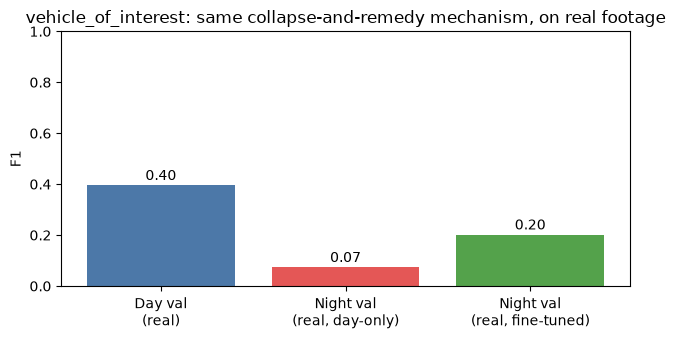

In [5]:
veh_day_score = evaluate_grid_detector(veh_day_model, veh_day_val_ds, WORK_W, WORK_H, device=device)
veh_night_score = evaluate_grid_detector(veh_day_model, veh_night_val_ds, WORK_W, WORK_H, device=device)
print(f"Day   val (real) -> F1 {veh_day_score.f1:.2f}")
print(f"Night val (real, day-only model) -> F1 {veh_night_score.f1:.2f}")

import copy
veh_night_finetune_ds = UAVDTVehicleDataset(index, NIGHT_FINETUNE_SEQS, stride=6, cap=60, seed=21)
veh_night_finetune_loader = DataLoader(veh_night_finetune_ds, batch_size=8, shuffle=True)
veh_finetuned_model = copy.deepcopy(veh_day_model)
train_grid_detector(veh_finetuned_model, veh_night_finetune_loader, epochs=20, lr=2e-4, device=device, quiet=True)
veh_finetuned_score = evaluate_grid_detector(veh_finetuned_model, veh_night_val_ds, WORK_W, WORK_H, device=device)
print(f"Night val (real, fine-tuned) -> F1 {veh_finetuned_score.f1:.2f}")

fig, ax = plt.subplots(figsize=(6.5, 3.5))
names = ["Day val\n(real)", "Night val\n(real, day-only)", "Night val\n(real, fine-tuned)"]
f1s = [veh_day_score.f1, veh_night_score.f1, veh_finetuned_score.f1]
bars = ax.bar(names, f1s, color=["#4C78A8", "#E45756", "#54A24B"])
ax.set_ylim(0, 1.0)
ax.set_ylabel("F1")
ax.set_title("vehicle_of_interest: same collapse-and-remedy mechanism, on real footage")
for b, v in zip(bars, f1s, strict=True):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.02, f"{v:.2f}", ha="center")
plt.tight_layout()
plt.show()

## Takeaway

Read this against `01_domain_gap_evidence.ipynb` rather than in isolation: the same
collapse-then-partial-recovery shape showing up on real, independently-sourced drone
footage is evidence the synthetic mechanism generalizes, not just an artifact of a renderer
built to make a point. This trained `veh_finetuned_model` is also what
`03_model_comparison_bakeoff.ipynb` compares against stock YOLO11n.